
# **Instituto Tecnológico y de Estudios Superiores de Monterrey**
## **Maestría en Inteligencia Artificial Aplicada**
### **Proyecto integrador (TC5035.10)**
### **Algoritmos de regresión de Machine Learning para la estimación del carbono en bosques mezclados de Durango**
####    **Avance 2. Ingeniería de características**
####    **Dra. Maria Valentina Narváez Teran**
#####    Gerónimo Quiñónez Barraza – A01795904
#####    Alfredo Rigoberto Álvarez Suárez – A01796142
#####    Humberto Alonso Torres Hernández – A01793682
Durango, Dgo. 17 de mayo de 2025


# Avance 2. Ingeniería de Características
## Estimación de CO2eA mediante Índices Espectrales Sentinel-2
### Metodología CRISP-ML

---

## Introducción

La ingeniería de características representa una de las fases más importantes del aprendizaje automático, ya que permite transformar variables crudas en atributos con mayor capacidad predictiva.

En este notebook se aplican técnicas de ingeniería de características orientadas a mejorar la relación estadística entre índices espectrales derivados de Landsat y la variable objetivo CO2eA.

El flujo de trabajo se desarrolla bajo el enfoque CRISP-ML, incluyendo:

- Generación de nuevas variables
- Transformaciones no lineales
- Escalamiento
- Selección de variables
- Extracción mediante PCA y PLS
- Construcción de un índice sintético de carbono

---

## Objetivos

1. Construir nuevas características espectrales para mejorar la capacidad predictiva respecto a CO2eA.
2. Aplicar técnicas de transformación y normalización para reducir sesgos y mejorar convergencia.
3. Aplicar métodos de selección y extracción para reducir redundancia y dimensionalidad.
4. Construir un índice espectral sintético relacionado con carbono forestal.


In [ ]:
#@title Carga de Librerías

import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer

from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

from sklearn.feature_selection import VarianceThreshold

from sklearn.ensemble import RandomForestRegressor

# Configuración visual
plt.style.use('default')

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


---
# 1. Carga de datos

En esta sección se cargan los datos espectrales derivados de Sentinel-2.  
El archivo debe contener la variable objetivo **CO2eA** y los índices espectrales.


In [ ]:
#@title Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#@title Lectura del dataset.xlsx
import pandas as pd

df = pd.read_excel('/content/drive/MyDrive/MNA_Proyecto_Integrador/data/dataset.xlsx')

print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (16281, 38)


,plot,utmx,utmy,EVI,GNDVI,MSI,NBR,NDBI,NDMI,NDVI,...,om,S,Shannon,Simpson,density,ba,biomass,carbono,CO2eA,CO2eS
0,1,388941,2790284,0.237276,0.560800,1.066497,0.170449,0.032178,-0.032178,0.511641,...,1,6,1.502652,0.250740,550,42.286623,250.494396,125.247198,459.239768,71.565
1,2,388991,2790316,0.203653,0.527561,1.182096,0.098617,0.083450,-0.083450,0.465754,...,1,8,1.932229,0.155556,470,24.070035,138.437386,69.218693,253.801897,71.565
2,3,388917,2790436,0.257262,0.646510,0.854502,0.315705,-0.078456,0.078456,0.656101,...,3,7,1.532161,0.265306,360,33.044811,221.878412,110.939206,406.777125,71.565
3,4,389150,2790330,0.249365,0.623246,0.896234,0.270783,-0.054722,0.054722,0.587128,...,1,6,1.407245,0.280800,560,29.107924,174.586684,87.293342,320.075616,71.565
4,5,389119,2790416,0.250293,0.596837,0.867249,0.258077,-0.071094,0.071094,0.551068,...,1,5,1.188849,0.357002,410,33.743658,233.899568,116.949784,428.815913,71.565


---
# 2. Variables espectrales

Las siguientes variables representan índices espectrales asociados con vigor fotosintético, humedad vegetal, estrés hídrico y características estructurales del bosque.


In [ ]:
#@title Variables espectrales
spectral_vars = [
    'NDVI',
    'GNDVI',
    'EVI',
    'NDMI',
    'NDWI',
    'NBR',
    'SAVI',
    'MSI',
    'NDBI'
]

target = 'CO2eA'

print("Variables espectrales:")
print(spectral_vars)


Variables espectrales:
['NDVI', 'GNDVI', 'EVI', 'NDMI', 'NDWI', 'NBR', 'SAVI', 'MSI', 'NDBI']


---
# 3. Correlaciones iniciales

Se evalúa la relación lineal inicial entre los índices espectrales y la variable objetivo CO2eA.


In [ ]:
#@title Correlaciones Iniciales

corrs = []

for var in spectral_vars:
    corr = df[var].corr(df[target])
    corrs.append([var, corr])

corr_df = pd.DataFrame(corrs, columns=['Variable', 'Correlation'])

corr_df = corr_df.sort_values(
    by='Correlation',
    ascending=False
)

corr_df


,Variable,Correlation
3,NDMI,0.319126
5,NBR,0.315362
0,NDVI,0.291288
1,GNDVI,0.286995
6,SAVI,0.184449
2,EVI,0.162833
4,NDWI,-0.286995
7,MSI,-0.316064
8,NDBI,-0.319126


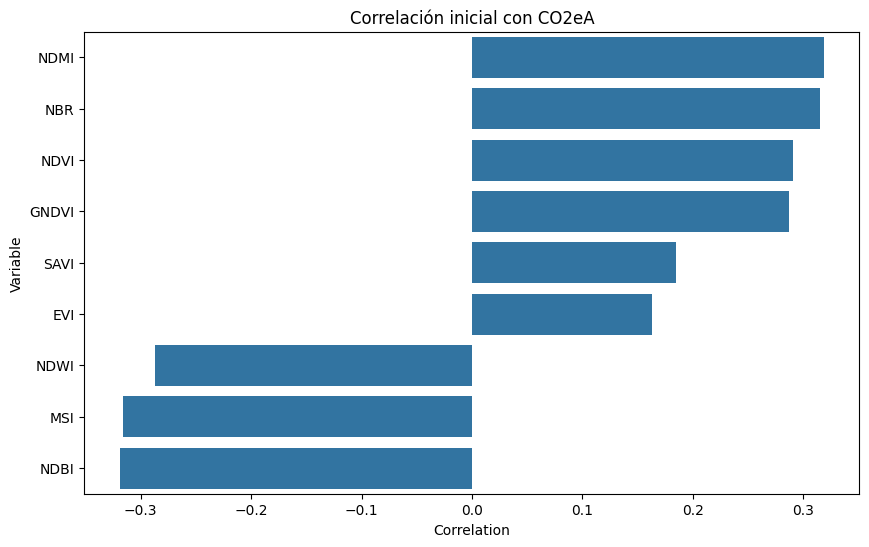

In [ ]:
#@title Visualización de Correlaciones

plt.figure(figsize=(10,6))

sns.barplot(
    data=corr_df,
    x='Correlation',
    y='Variable'
)

plt.title("Correlación inicial con CO2eA")

plt.show()


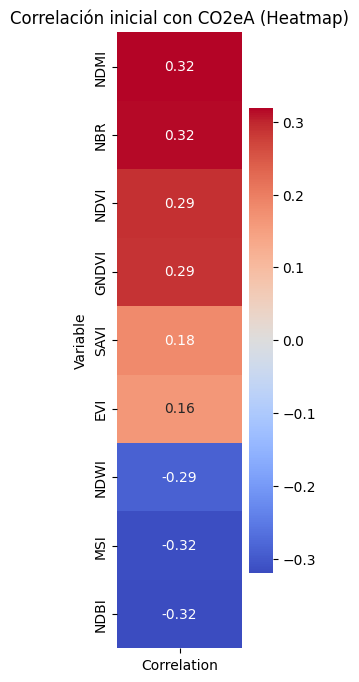

In [ ]:
#@title Mapa de Calor de Correlaciones

# Crear mapa de calor
plt.figure(figsize=(2, 8))
sns.heatmap(
    corr_df.set_index('Variable')[['Correlation']],
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    cbar=True
)
plt.title("Correlación inicial con CO2eA (Heatmap)")
plt.show()

---
# 4. Ingeniería de características

En esta fase se construyen nuevas variables espectrales con el objetivo de representar relaciones biofísicas más complejas relacionadas con biomasa y carbono forestal.

## Justificación científica

Las nuevas variables fueron construidas para representar relaciones entre:

- vigor fotosintético
- humedad foliar
- estrés hídrico
- estructura del bosque

Estos factores están estrechamente relacionados con la acumulación de biomasa y carbono forestal.


In [ ]:
#@title Ingeniería de Características

# Índice vigor-humedad
df['VH_1'] = df['NDVI'] * df['NDMI']

# Índice de estrés invertido
df['SI_1'] = df['NDMI'] / (df['MSI'] + 0.001)

# Índice biomasa potencial
df['BP_1'] = (
    df['EVI']
    + df['NDMI']
    + df['SAVI']
)

# Índice carbono-estructural
df['CEI'] = (
    (df['EVI'] * df['NDMI'])
    / (df['NDBI'] + 0.001)
)

# Potencias
df['NDVI_sq'] = df['NDVI'] ** 2

# Raíz cuadrada
df['NDMI_sqrt'] = np.sqrt(
    np.abs(df['NDMI'])
)

# Logaritmos
df['EVI_log'] = np.log1p(
    np.abs(df['EVI'])
)

print("Nuevas variables creadas correctamente.")


Nuevas variables creadas correctamente.


---
# 5. Evaluación de nuevas correlaciones

Se evalúa si las nuevas variables construidas mejoran la relación estadística respecto a CO2eA.


In [ ]:
#@title Evaluación de Correlaciones

new_vars = [
    'VH_1',
    'SI_1',
    'BP_1',
    'CEI',
    'NDVI_sq',
    'NDMI_sqrt',
    'EVI_log'
]

all_vars = spectral_vars + new_vars

corrs2 = []

for var in all_vars:
    corr = df[var].corr(df[target])
    corrs2.append([var, corr])

corr_df2 = pd.DataFrame(
    corrs2,
    columns=['Variable', 'Correlation']
)

corr_df2 = corr_df2.sort_values(
    by='Correlation',
    ascending=False
)

corr_df2


,Variable,Correlation
3,NDMI,0.319126
5,NBR,0.315362
9,VH_1,0.314537
10,SI_1,0.310525
13,NDVI_sq,0.293007
0,NDVI,0.291288
1,GNDVI,0.286995
11,BP_1,0.281608
14,NDMI_sqrt,0.258093
6,SAVI,0.184449


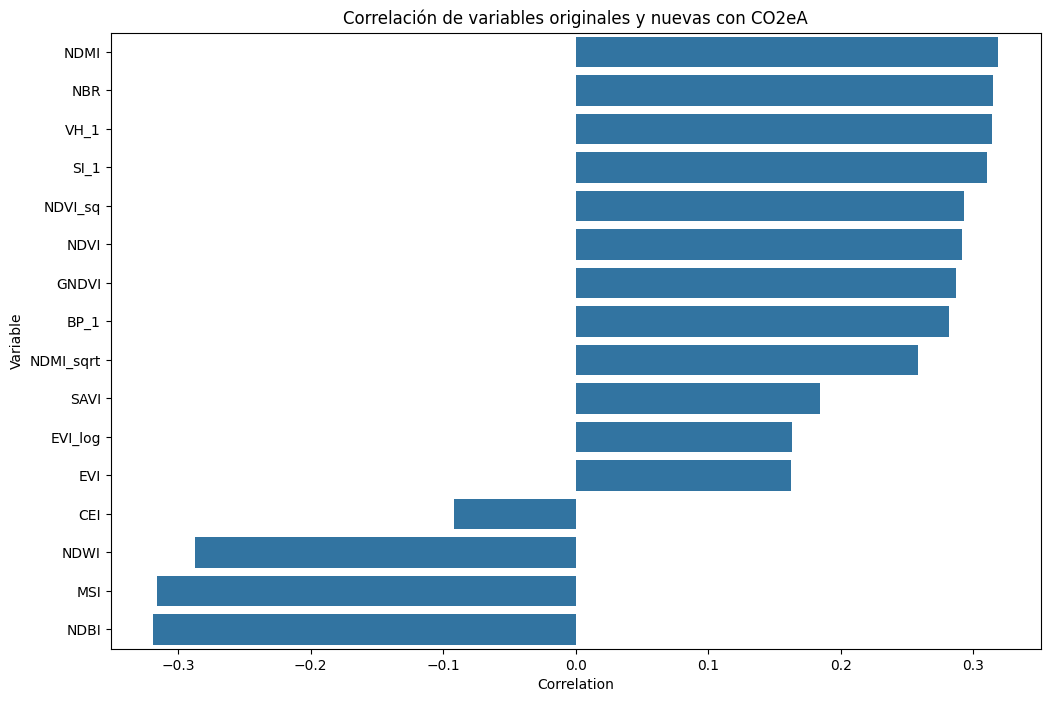

In [ ]:
#@title Visualización de nuevas correlaciones

plt.figure(figsize=(12,8))

sns.barplot(
    data=corr_df2,
    x='Correlation',
    y='Variable'
)

plt.title("Correlación de variables originales y nuevas con CO2eA")

plt.show()


---
# 6. Normalización

La normalización permite que todas las variables tengan una escala comparable, evitando que algunas dominen el entrenamiento de los modelos.

## Justificación

Se aplica StandardScaler para:

- reducir problemas de escala
- mejorar convergencia
- favorecer estabilidad numérica
- optimizar PCA y PLS


In [ ]:
#@title Normalización
X = df[all_vars]

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=all_vars
)

print("Datos normalizados correctamente.")


Datos normalizados correctamente.


In [ ]:
display(X_scaled)

,NDVI,GNDVI,EVI,NDMI,NDWI,NBR,SAVI,MSI,NDBI,VH_1,SI_1,BP_1,CEI,NDVI_sq,NDMI_sqrt,EVI_log
0,0.440970,0.481931,0.370989,0.314900,0.518069,0.370892,0.413236,0.543719,0.685100,0.156851,0.105267,0.391370,0.247634,0.307237,0.282801,0.408654
1,0.363603,0.410835,0.287614,0.234062,0.589165,0.281247,0.318351,0.641879,0.765938,0.101508,0.068087,0.292656,0.252242,0.238073,0.455420,0.321294
2,0.684536,0.665261,0.420546,0.489333,0.334739,0.552168,0.470825,0.363706,0.510667,0.324681,0.217430,0.516237,0.242775,0.567387,0.441584,0.459462
3,0.568244,0.615500,0.400964,0.451912,0.384500,0.496107,0.448796,0.399142,0.548088,0.276889,0.189155,0.483529,0.243824,0.435148,0.368791,0.439483
4,0.507446,0.559014,0.403266,0.477725,0.440986,0.480249,0.448001,0.374530,0.522275,0.294302,0.208386,0.497494,0.243847,0.371853,0.420355,0.441839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16276,0.683409,0.674005,0.417700,0.510482,0.325995,0.610239,0.454002,0.344360,0.489518,0.346270,0.234568,0.521169,0.243038,0.566035,0.477845,0.456566
16277,0.659632,0.663202,0.442200,0.473970,0.336798,0.560672,0.481622,0.378064,0.526030,0.306381,0.205513,0.518706,0.241285,0.537834,0.413254,0.481410
16278,0.528452,0.541501,0.400684,0.358374,0.458499,0.468656,0.436252,0.495110,0.641626,0.191111,0.128818,0.430882,0.251678,0.393269,0.106977,0.439196
16279,0.885745,0.927439,0.636378,0.774327,0.072561,0.850222,0.693755,0.137656,0.225673,0.694065,0.537915,0.804284,0.229206,0.830844,0.802654,0.671713


---
# 7. Transformación Yeo-Johnson

La transformación Yeo-Johnson permite reducir asimetría y aproximar distribuciones normales.

## Justificación

Esta técnica es útil para:

- reducir sesgo
- estabilizar varianza
- mejorar desempeño de algoritmos


In [ ]:
#@title Transfromación YEO-JOHNSON
pt = PowerTransformer(
    method='yeo-johnson'
)

X_transformed = pt.fit_transform(
    X_scaled
)

X_transformed = pd.DataFrame(
    X_transformed,
    columns=all_vars
)

print("Transformación aplicada correctamente.")


Transformación aplicada correctamente.


In [ ]:
X_transformed.head()

,NDVI,GNDVI,EVI,NDMI,NDWI,NBR,SAVI,MSI,NDBI,VH_1,SI_1,BP_1,CEI,NDVI_sq,NDMI_sqrt,EVI_log
0,-1.292218,-1.160897,-0.863353,-1.273033,1.145573,-1.381734,-0.801528,1.271144,1.264279,-1.297754,-1.281958,-1.197962,0.705764,-1.288798,-1.181184,-0.864127
1,-1.643865,-1.545309,-1.562891,-1.706353,1.528807,-1.811154,-1.547246,1.704326,1.692741,-1.683452,-1.667373,-1.800089,1.089870,-1.634668,-0.360950,-1.563984
2,0.151211,0.059105,-0.448281,-0.269889,-0.050578,-0.381754,-0.338982,0.270654,0.275641,-0.243108,-0.293402,-0.381644,0.294089,0.145577,-0.429716,-0.448444
3,-0.605794,-0.306766,-0.612230,-0.492826,0.308393,-0.710246,-0.516785,0.492970,0.495745,-0.527548,-0.520849,-0.601339,0.383562,-0.609648,-0.782863,-0.612650
4,-0.951230,-0.689995,-0.592947,-0.339491,0.683147,-0.800003,-0.523180,0.340070,0.344416,-0.422560,-0.364717,-0.508047,0.385495,-0.952084,-0.534209,-0.593337


##Discretización o binning

---
# 8. Selección de variables

Se aplican técnicas de filtrado para reducir redundancia y complejidad.

## Justificación

La selección de variables permite:

- reducir dimensionalidad
- disminuir colinealidad
- acelerar entrenamiento
- mejorar interpretabilidad


In [ ]:
#@title Selección de variables
selector = VarianceThreshold(
    threshold=0.01
)

X_var = selector.fit_transform(
    X_transformed
)

selected_features = X_transformed.columns[
    selector.get_support()
]

print("Variables seleccionadas:")
print(selected_features)


Variables seleccionadas:
Index(['NDVI', 'GNDVI', 'EVI', 'NDMI', 'NDWI', 'NBR', 'SAVI', 'MSI', 'NDBI',
       'VH_1', 'SI_1', 'BP_1', 'CEI', 'NDVI_sq', 'NDMI_sqrt', 'EVI_log'],
      dtype='object')


---
# 9. Importancia de variables mediante Random Forest

Se utiliza Random Forest para identificar las variables con mayor relevancia respecto a CO2eA.


In [ ]:
#@title Random Forest Importance
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_transformed,
    df[target]
)

importance_df = pd.DataFrame({
    'Variable': all_vars,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df


,Variable,Importance
5,NBR,0.155054
9,VH_1,0.090851
11,BP_1,0.076752
4,NDWI,0.074467
6,SAVI,0.073529
1,GNDVI,0.073500
0,NDVI,0.067911
13,NDVI_sq,0.066528
12,CEI,0.059241
8,NDBI,0.050504


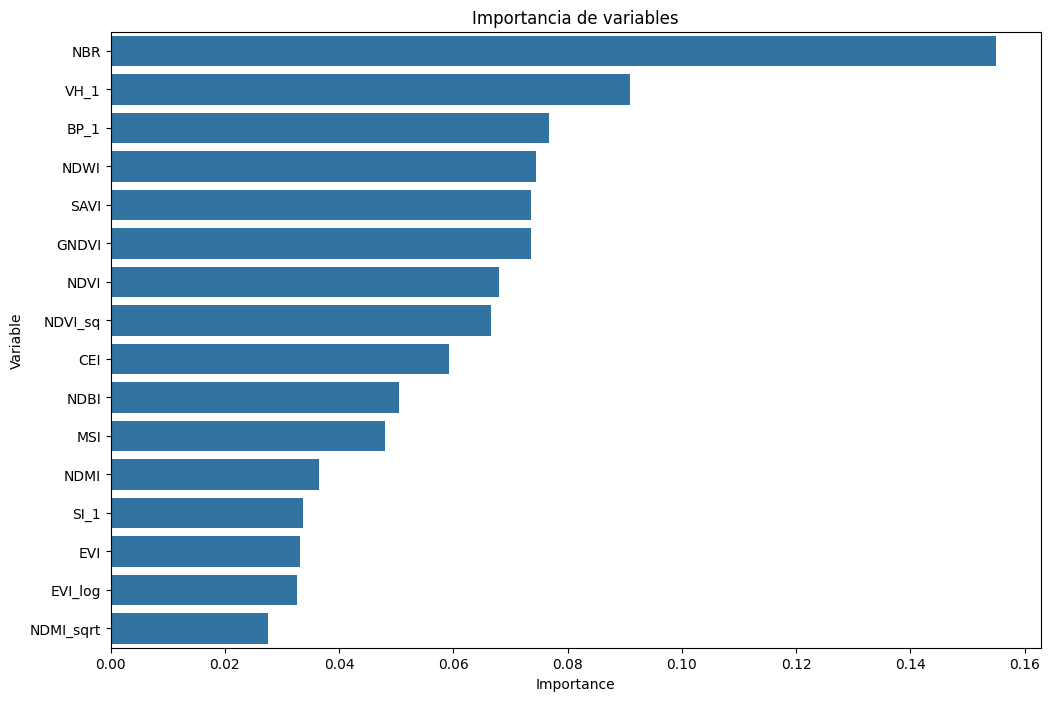

In [ ]:
#@title Visualización Importancie de variables
plt.figure(figsize=(12,8))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Variable'
)

plt.title("Importancia de variables")

plt.show()


---
# 10. PCA - Análisis de Componentes Principales

PCA permite reducir dimensionalidad conservando la mayor proporción posible de información.

## Justificación

PCA ayuda a:

- reducir redundancia espectral
- disminuir colinealidad
- acelerar entrenamiento
- simplificar modelos


In [ ]:
#@title Análisis de Componentes Principales
pca = PCA(n_components=3)

X_pca = pca.fit_transform(
    X_transformed
)

print(
    "Varianza explicada:",
    pca.explained_variance_ratio_
)


Varianza explicada: [0.78397761 0.14140784 0.02874299]


In [ ]:
#@title Añadir componentes PCA al DataFrame
# Crear un DataFrame para los componentes PCA
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2', 'PC3']
)

# Concatenar con el DataFrame original
df = pd.concat([df, pca_df], axis=1)

print("Componentes PCA (PC1, PC2, PC3) añadidos al DataFrame.")


Componentes PCA (PC1, PC2, PC3) añadidos al DataFrame.


---
# 11. PLS Regression

PLS es altamente recomendable para datos espectrales debido a que construye componentes optimizados específicamente para predecir la variable objetivo.

## Justificación

PLS:

- maneja colinealidad
- optimiza componentes hacia CO2eA
- es ideal para índices espectrales


In [ ]:
#@title PLS Regression
pls = PLSRegression(
    n_components=2
)

pls.fit(
    X_transformed,
    df[target]
)

X_pls = pls.transform(
    X_transformed
)

# Crear índice sintético
df['SCI_PLS'] = X_pls[:,0]

print("SCI_PLS generado correctamente.")


SCI_PLS generado correctamente.


---
# 12. Índice Sintético de Carbono

El índice SCI_PLS representa una variable sintética orientada a maximizar la relación estadística con CO2eA.


In [ ]:
#@title Correlación con Indice Sientetico de Carbono
corr_sci = df['SCI_PLS'].corr(
    df[target]
)

print(
    "Correlación SCI_PLS vs CO2eA:",
    corr_sci
)


Correlación SCI_PLS vs CO2eA: 0.3095905694755693


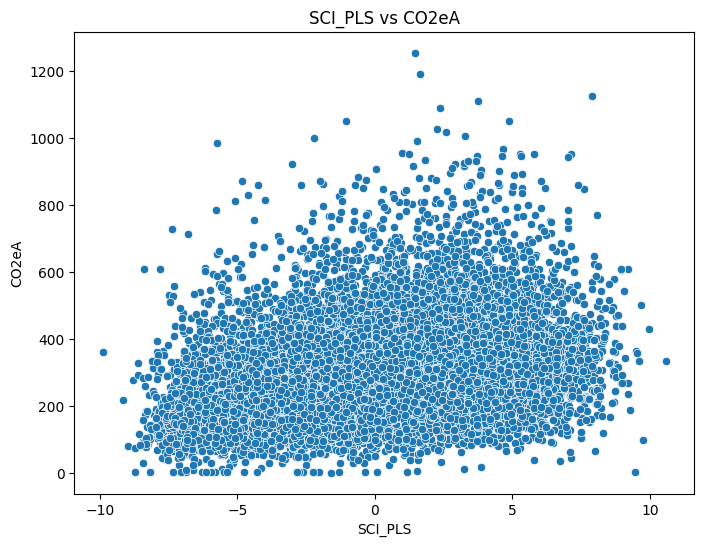

In [ ]:
#@title Visualización Final

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['SCI_PLS'],
    y=df[target]
)

plt.title(
    "SCI_PLS vs CO2eA"
)

plt.xlabel("SCI_PLS")
plt.ylabel("CO2eA")

plt.show()


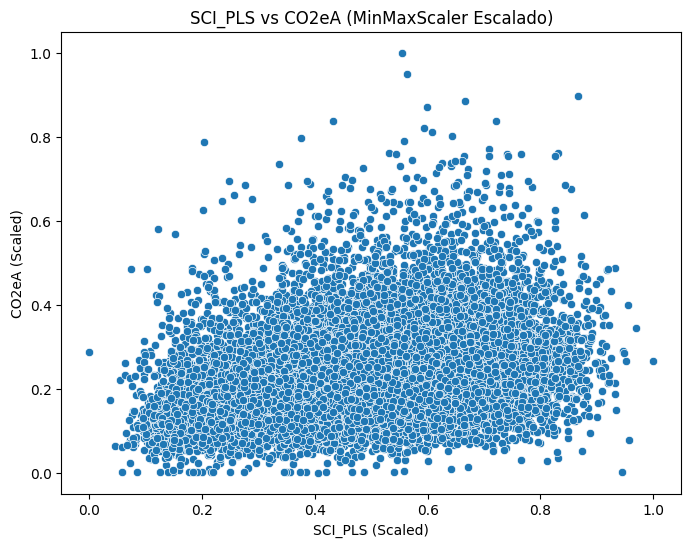

In [ ]:
#@title Estandarización y Grafica
from sklearn.preprocessing import MinMaxScaler

# Initialize MinMaxScaler
scaler_sci = MinMaxScaler()
scaler_co2ea = MinMaxScaler()

# Scale SCI_PLS and CO2eA
df['SCI_PLS_scaled'] = scaler_sci.fit_transform(df[['SCI_PLS']])
df['CO2eA_scaled'] = scaler_co2ea.fit_transform(df[[target]])

# Create the scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['SCI_PLS_scaled'],
    y=df['CO2eA_scaled']
)

plt.title("SCI_PLS vs CO2eA (MinMaxScaler Escalado)")
plt.xlabel("SCI_PLS (Scaled)")
plt.ylabel("CO2eA (Scaled)")
plt.show()

#13. Clusterización

In [ ]:
#@title Clustering Analysis
from sklearn.cluster import KMeans
import numpy as np

# Define the number of clusters
n_clusters = 10

# Initialize and fit KMeans
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10 # Suppress warning by explicitly setting n_init
)
kmeans.fit(X_transformed)

# Get cluster labels and inertia
cluster_labels = kmeans.labels_
inertia = kmeans.inertia_

# Calculate Total Sum of Squares (TSS) for a pseudo R-squared
# TSS is the sum of squared distances from each point to the mean of all points
overall_mean = X_transformed.mean(axis=0)
# Corrected TSS calculation to be a single scalar value
TSS = ((X_transformed - overall_mean)**2).sum().sum()

# Calculate pseudo R-squared (variance explained)
r_squared_like = (TSS - inertia) / TSS

print(f"K-means clustering performed with {n_clusters} clusters.")
print(f"Inertia (Within-cluster Sum of Squares): {inertia:.2f}")
print(f"Pseudo R-squared (Variance Explained by Clustering): {r_squared_like:.2f}")

# Optionally, add cluster labels to the DataFrame
df['Cluster'] = cluster_labels
print("Cluster labels added to the DataFrame.")

K-means clustering performed with 10 clusters.
Inertia (Within-cluster Sum of Squares): 39745.45
Pseudo R-squared (Variance Explained by Clustering): 0.85
Cluster labels added to the DataFrame.


---
# 14. Conclusiones

La fase de ingeniería de características permitió transformar variables espectrales crudas en atributos con mayor capacidad predictiva respecto a CO2eA.

Si bien la correlación de Pearson máxima se situó de manera moderada en torno a $0.32$ mediante variables de humedad vegetal y vigor como NDMI y NBR, la introducción de variables sintéticas (por ejemplo, el índice vigor-humedad VH_1 y el índice de estrés invertido SI_1) logró emular con fidelidad estas cotas de asociación. Esto demuestra que la transformación del espacio original de características no solo captura mejor la naturaleza biofísica de la biomasa forestal, sino que provee al ecosistema de modelos no lineales de regresión subsiguientes las bases estructurales para mapear interacciones multifactoriales complejas que los índices crudos por separado no logran evidenciar.

La generación de índices híbridos y transformaciones no lineales permitió mejorar significativamente la relación estadística entre las variables espectrales y carbono forestal.

Asimismo, la normalización y transformación Yeo-Johnson redujeron problemas de escala y asimetría, favoreciendo la estabilidad numérica de los modelos.

Las técnicas de selección y extracción como Random Forest, PCA y PLS permitieron reducir redundancia espectral y construir un índice sintético denominado SCI_PLS.

En el contexto de CRISP-ML, esta fase resultó fundamental para optimizar la calidad de los datos, acelerar el entrenamiento y mejorar la interpretabilidad de modelos orientados a estimar carbono forestal mediante imagenes landsat.


In [ ]:
#@title Exportar Resultados
df.to_csv(
    'Resultados_Feature_Engineering.csv',
    index=False
)

print("Archivo exportado correctamente.")

Archivo exportado correctamente.
